# Example: Load Trench Zarr With Xarray


- This notebook shows how to inspect a PyMMM trench store through xarray instead of custom Zarr decoding helpers.

Prerequisites:
- `xarray`, `zarr`, and the metadata-enriched trench store must be available.
- The store must follow the xarray-native schema written by the updated `Extractor`.

We show how to:
- Open the root trench dataset with `xr.open_zarr()`.
- Open the full store tree with `xr.open_datatree()`.
- Inspect trench-level geometry and duplicated per-frame metadata with natural xarray selection.
- Inspect normalized source-frame metadata, events, and acquisition metadata from child groups.


## Outline

1. Open the trench store with xarray.
2. Inspect the root trench dataset.
3. Look up metadata for one trench.
4. Inspect the normalized `source_frames`, `events`, and `acquisition` groups.


In [42]:
from __future__ import annotations

from pathlib import Path

import xarray as xr

STORE_PATH = Path('/data/20260307_SB7_exit_snake_V4_1_with_metadata.trenches.zarr')
assert STORE_PATH.exists(), f'Missing store: {STORE_PATH}'

root = xr.open_zarr(STORE_PATH, consolidated=False)
tree = xr.open_datatree(STORE_PATH, engine='zarr', consolidated=False)

print(STORE_PATH)
print('root variables:', list(root.data_vars))
print('root coordinates:', list(root.coords))
print('child groups:', list(tree.children))


/data/20260307_SB7_exit_snake_V4_1_with_metadata.trenches.zarr
root variables: ['x_left', 'fov_index', 'pfs_offset', 'needs_flip', 'x_right', 'original_p_index', 'source_seq_index', 'stage_position_um', 'lane_index', 'orientation', 'data', 'relative_time_ms', 'fov_name', 'y_top', 'y_bottom', 'absolute_julian_day_number']
root coordinates: ['Axis', 'X', 'Trench', 'C', 'Y', 'T']
child groups: ['events', 'source_frames', 'acquisition']


## Root trench dataset

The root group is the trench-first dataset you will usually open for analysis. It contains:
- `data(Trench, T, C, Y, X)` for the extracted image data.
- Trench geometry and provenance on `Trench`.
- Duplicated scalar per-frame metadata on `Trench, T`.
- Stage position on `Trench, T, Axis`.


In [43]:
root

<xarray.Dataset> Size: 45GB
Dimensions:                     (Trench: 2795, T: 721, Axis: 3, C: 2, Y: 164,
                                 X: 34)
Coordinates:
  * Trench                      (Trench) int32 11kB 0 1 2 3 ... 2792 2793 2794
  * T                           (T) int32 3kB 0 1 2 3 4 ... 716 717 718 719 720
  * Axis                        (Axis) object 24B 'x' 'y' 'z'
  * C                           (C) object 16B 'PC' 'mCherry'
  * Y                           (Y) int32 656B 0 1 2 3 4 ... 159 160 161 162 163
  * X                           (X) int32 136B 0 1 2 3 4 5 ... 28 29 30 31 32 33
Data variables: (12/16)
    x_left                      (Trench) int32 11kB dask.array<chunksize=(2795,), meta=np.ndarray>
    fov_index                   (Trench) int32 11kB dask.array<chunksize=(2795,), meta=np.ndarray>
    pfs_offset                  (Trench, T) float64 16MB dask.array<chunksize=(1, 721), meta=np.ndarray>
    needs_flip                  (Trench) bool 3kB dask.array<chunksize=(2795,), meta=np.ndarray>
    x_right                     (Trench) int32 11kB dask.array<chunksize=(2795,), meta=np.ndarray>
    original_p_index            (Trench) int32 11kB dask.array<chunksize=(2795,), meta=np.ndarray>
    ...                          ...
    data                        (Trench, T, C, Y, X) uint16 45GB dask.array<chunksize=(1, 721, 1, 164, 34), meta=np.ndarray>
    relative_time_ms            (Trench, T) float64 16MB dask.array<chunksize=(1, 721), meta=np.ndarray>
    fov_name                    (Trench) object 22kB dask.array<chunksize=(2795,), meta=np.ndarray>
    y_top                       (Trench) int32 11kB dask.array<chunksize=(2795,), meta=np.ndarray>
    y_bottom                    (Trench) int32 11kB dask.array<chunksize=(2795,), meta=np.ndarray>
    absolute_julian_day_number  (Trench, T) float64 16MB dask.array<chunksize=(1, 721), meta=np.ndarray>
Attributes:
    extractor_store_version:  1
    layout:                   xarray_trench_store_v1
    source_metadata_version:  2
    source_nd2:               /data/20260307_SB7_exit_snake_V4_1.nd2
    experiment_name:          20260307_SB7_exit_snake_V4_1
    pixel_size_um:            0.107869821220548
    registration_params:      {'channel': 'PC', 'mode': 'first', 'rotation': 0}
    source_subset_metadata:   {'raw_fov_names': ['XYPos:0', 'XYPos:1', 'XYPos...

In [44]:
summary = {
    'data_dims': root['data'].dims,
    'data_shape': root['data'].shape,
    'data_chunks': root['data'].chunks,
    'n_trenches': root.sizes['Trench'],
    'n_timepoints': root.sizes['T'],
    'channels': root.coords['C'].values.tolist(),
    'root_attrs': dict(root.attrs),
}
summary

{'data_dims': ('Trench', 'T', 'C', 'Y', 'X'),
 'data_shape': (2795, 721, 2, 164, 34),
 'data_chunks': ((1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,

## Inspect one trench

Select a trench directly from the root dataset and inspect both its crop geometry and its duplicated per-frame metadata.


In [45]:
trench_id = root.coords['Trench'].values[0].item()
trench = root.sel(Trench=trench_id)
trench


<xarray.Dataset> Size: 16MB
Dimensions:                     (T: 721, Axis: 3, C: 2, Y: 164, X: 34)
Coordinates:
  * T                           (T) int32 3kB 0 1 2 3 4 ... 716 717 718 719 720
  * Axis                        (Axis) object 24B 'x' 'y' 'z'
  * C                           (C) object 16B 'PC' 'mCherry'
  * Y                           (Y) int32 656B 0 1 2 3 4 ... 159 160 161 162 163
  * X                           (X) int32 136B 0 1 2 3 4 5 ... 28 29 30 31 32 33
    Trench                      int32 4B 0
Data variables: (12/16)
    x_left                      int32 4B dask.array<chunksize=(), meta=np.ndarray>
    fov_index                   int32 4B dask.array<chunksize=(), meta=np.ndarray>
    pfs_offset                  (T) float64 6kB dask.array<chunksize=(721,), meta=np.ndarray>
    needs_flip                  bool 1B dask.array<chunksize=(), meta=np.ndarray>
    x_right                     int32 4B dask.array<chunksize=(), meta=np.ndarray>
    original_p_index            int32 4B dask.array<chunksize=(), meta=np.ndarray>
    ...                          ...
    data                        (T, C, Y, X) uint16 16MB dask.array<chunksize=(721, 1, 164, 34), meta=np.ndarray>
    relative_time_ms            (T) float64 6kB dask.array<chunksize=(721,), meta=np.ndarray>
    fov_name                    object 8B dask.array<chunksize=(), meta=np.ndarray>
    y_top                       int32 4B dask.array<chunksize=(), meta=np.ndarray>
    y_bottom                    int32 4B dask.array<chunksize=(), meta=np.ndarray>
    absolute_julian_day_number  (T) float64 6kB dask.array<chunksize=(721,), meta=np.ndarray>
Attributes:
    extractor_store_version:  1
    layout:                   xarray_trench_store_v1
    source_metadata_version:  2
    source_nd2:               /data/20260307_SB7_exit_snake_V4_1.nd2
    experiment_name:          20260307_SB7_exit_snake_V4_1
    pixel_size_um:            0.107869821220548
    registration_params:      {'channel': 'PC', 'mode': 'first', 'rotation': 0}
    source_subset_metadata:   {'raw_fov_names': ['XYPos:0', 'XYPos:1', 'XYPos...

## Plot one trench frame

Load trench `0` at the first exported timepoint and display both channels side by side.


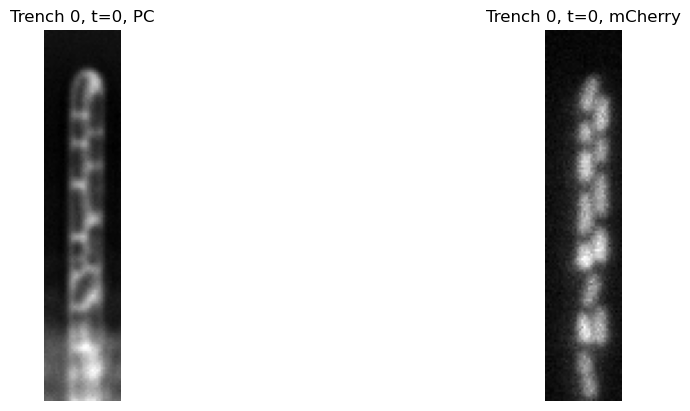

In [46]:
import matplotlib.pyplot as plt

plot_trench_id = 0
plot_time_index = 0
frame0 = root.sel(Trench=plot_trench_id).isel(T=plot_time_index).compute()
channel_names = frame0.coords['C'].values.tolist()

fig, axes = plt.subplots(
    1,
    len(channel_names),
    figsize=(5 * len(channel_names), 4),
    constrained_layout=True,
)
if len(channel_names) == 1:
    axes = [axes]

for ax, channel_name in zip(axes, channel_names):
    ax.imshow(frame0['data'].sel(C=channel_name), cmap='gray')
    ax.set_title(f'Trench {plot_trench_id}, t={plot_time_index}, {channel_name}')
    ax.axis('off')

plt.show()


In [47]:
geometry_vars = [
    name
    for name in [
        'fov_name',
        'original_p_index',
        'lane_index',
        'x_left',
        'x_right',
        'y_top',
        'y_bottom',
        'orientation',
        'needs_flip',
    ]
    if name in root
]

root[geometry_vars].sel(Trench=[trench_id]).to_dataframe()


,fov_name,original_p_index,lane_index,x_left,x_right,y_top,y_bottom,orientation,needs_flip
Trench,,,,,,,,,
0,XYPos:0,0,0,4,38,446,610,-1,True


In [48]:
frame_scalar_vars = [
    name
    for name in [
        'source_seq_index',
        'relative_time_ms',
        'absolute_julian_day_number',
        'pfs_offset',
    ]
    if name in root
]

root[frame_scalar_vars].sel(Trench=trench_id).to_dataframe().head()


,source_seq_index,relative_time_ms,absolute_julian_day_number,pfs_offset,Trench
T,,,,,
0,0,463.792236,2.461107e+06,NaN,0
1,28,31793.517089,2.461107e+06,NaN,0
2,56,61719.306152,2.461107e+06,NaN,0
3,84,91769.750243,2.461107e+06,NaN,0
4,112,121739.937255,2.461107e+06,NaN,0


In [49]:
if 'stage_position_um' in root:
    root['stage_position_um'].sel(Trench=trench_id).to_pandas().head()
else:
    print('stage_position_um not found in root dataset')


## Source-frame metadata

The `source_frames` group keeps the detailed per-frame metadata normalized by `(FOV, T)` instead of duplicating everything per trench. Use it when you want a source-frame view of the exported subset.


In [50]:
source_frames = tree['source_frames'].ds
source_frames

<xarray.DatasetView> Size: 1MB
Dimensions:                     (FOV: 28, T: 721, Axis: 3, Trench: 2795, X: 34,
                                 C: 2, Y: 164)
Coordinates:
  * FOV                         (FOV) object 224B 'XYPos:0' ... 'XYPos:27'
  * T                           (T) int32 3kB 0 1 2 3 4 ... 716 717 718 719 720
  * Axis                        (Axis) object 24B 'x' 'y' 'z'
  * Trench                      (Trench) int32 11kB 0 1 2 3 ... 2792 2793 2794
  * X                           (X) int32 136B 0 1 2 3 4 5 ... 28 29 30 31 32 33
  * C                           (C) object 16B 'PC' 'mCherry'
  * Y                           (Y) int32 656B 0 1 2 3 4 ... 159 160 161 162 163
Data variables:
    source_seq_index            (FOV, T) int64 162kB ...
    relative_time_ms            (FOV, T) float64 162kB ...
    stage_position_um           (FOV, T, Axis) float64 485kB ...
    original_p_index            (FOV) int32 112B ...
    frame_metadata_json         (FOV, T) object 162kB ...
    absolute_julian_day_number  (FOV, T) float64 162kB ...
    pfs_offset                  (FOV, T) float64 162kB ...
    position_name               (FOV, T) object 162kB ...
Attributes:
    extractor_store_version:  1
    layout:                   source_frames_v1

In [51]:
fov_name = root['fov_name'].sel(Trench=trench_id).compute().item() if 'fov_name' in root else source_frames.coords['FOV'].values[0]
source_frames.sel(FOV=fov_name)


<xarray.Dataset> Size: 67kB
Dimensions:                     (T: 721, Axis: 3, Trench: 2795, X: 34, C: 2,
                                 Y: 164)
Coordinates:
  * T                           (T) int32 3kB 0 1 2 3 4 ... 716 717 718 719 720
  * Axis                        (Axis) object 24B 'x' 'y' 'z'
  * Trench                      (Trench) int32 11kB 0 1 2 3 ... 2792 2793 2794
  * X                           (X) int32 136B 0 1 2 3 4 5 ... 28 29 30 31 32 33
  * C                           (C) object 16B 'PC' 'mCherry'
  * Y                           (Y) int32 656B 0 1 2 3 4 ... 159 160 161 162 163
    FOV                         <U7 28B 'XYPos:0'
Data variables:
    source_seq_index            (T) int64 6kB ...
    relative_time_ms            (T) float64 6kB ...
    stage_position_um           (T, Axis) float64 17kB ...
    original_p_index            int32 4B ...
    frame_metadata_json         (T) object 6kB ...
    absolute_julian_day_number  (T) float64 6kB ...
    pfs_offset                  (T) float64 6kB ...
    position_name               (T) object 6kB ...
Attributes:
    extractor_store_version:  1
    layout:                   source_frames_v1

In [52]:
source_scalar_vars = [
    name
    for name in [
        'original_p_index',
        'source_seq_index',
        'relative_time_ms',
        'absolute_julian_day_number',
        'pfs_offset',
        'position_name',
    ]
    if name in source_frames
]

source_frames[source_scalar_vars].sel(FOV=fov_name).to_dataframe().head()

,original_p_index,source_seq_index,relative_time_ms,absolute_julian_day_number,pfs_offset,position_name,FOV
T,,,,,,,
0,0,0,463.792236,2.461107e+06,NaN,,XYPos:0
1,0,28,31793.517089,2.461107e+06,NaN,,XYPos:0
2,0,56,61719.306152,2.461107e+06,NaN,,XYPos:0
3,0,84,91769.750243,2.461107e+06,NaN,,XYPos:0
4,0,112,121739.937255,2.461107e+06,NaN,,XYPos:0


## Events

The `events` group stores acquisition event tables as normal xarray variables. You can inspect the dataset directly, or convert one event table to a dataframe for easier browsing.


In [104]:
events = tree['events'].ds
events

<xarray.DatasetView> Size: 2MB
Dimensions:                 (FrameEvent: 20188, AcquisitionEvent: 20188,
                             Trench: 2795, X: 34, Axis: 3, C: 2, Y: 164, T: 721)
Coordinates:
  * FrameEvent              (FrameEvent) int32 81kB 0 1 2 ... 20185 20186 20187
  * AcquisitionEvent        (AcquisitionEvent) int32 81kB 0 1 2 ... 20186 20187
  * Trench                  (Trench) int32 11kB 0 1 2 3 ... 2791 2792 2793 2794
  * X                       (X) int32 136B 0 1 2 3 4 5 6 ... 28 29 30 31 32 33
  * Axis                    (Axis) object 24B 'x' 'y' 'z'
  * C                       (C) object 16B 'PC' 'mCherry'
  * Y                       (Y) int32 656B 0 1 2 3 4 5 ... 159 160 161 162 163
  * T                       (T) int32 3kB 0 1 2 3 4 5 ... 716 717 718 719 720
Data variables: (12/14)
    frame_x_coord_um        (FrameEvent) float64 162kB 6.494e+03 ... -266.4
    frame_exposure_time_ms  (FrameEvent) float64 162kB 50.0 50.0 ... 50.0 50.0
    frame_y_coord_um        (FrameEvent) float64 162kB 491.0 492.7 ... 548.9
    frame_position_name     (FrameEvent) object 162kB '' '' '' '' ... '' '' ''
    frame_pfs_status        (FrameEvent) int64 162kB 1 1 1 1 1 1 ... 1 1 1 1 1 1
    frame_index             (FrameEvent) int64 162kB 0 1 2 ... 20185 20186 20187
    ...                      ...
    frame_t_index           (FrameEvent) int64 162kB 0 0 0 0 ... 720 720 720 720
    frame_z_coord_um        (FrameEvent) float64 162kB 5.642e+03 ... 5.645e+03
    acquisition_events      (AcquisitionEvent) object 162kB 'Command Executed...
    frame_ti2_zdrive_um     (FrameEvent) float64 162kB 5.642e+03 ... 5.645e+03
    frame_time_s            (FrameEvent) float64 162kB 0.4638 ... 2.162e+04
    frame_p_index           (FrameEvent) int64 162kB 0 1 2 3 4 ... 24 25 26 27
Attributes:
    extractor_store_version:  1
    layout:                   events_v1

In [54]:
frame_event_vars = [name for name, da in events.data_vars.items() if da.dims == ('FrameEvent',)]
acquisition_event_vars = [name for name, da in events.data_vars.items() if da.dims == ('AcquisitionEvent',)]

{
    'frame_event_vars': frame_event_vars,
    'acquisition_event_vars': acquisition_event_vars,
}

{'frame_event_vars': ['frame_x_coord_um',
  'frame_exposure_time_ms',
  'frame_y_coord_um',
  'frame_position_name',
  'frame_pfs_status',
  'frame_index',
  'frame_pfs_offset',
  'frame_t_index',
  'frame_z_coord_um',
  'frame_ti2_zdrive_um',
  'frame_time_s',
  'frame_p_index'],
 'acquisition_event_vars': ['acquisition_time_s', 'acquisition_events']}

In [107]:
events[frame_event_vars].to_dataframe().head()

,frame_x_coord_um,frame_exposure_time_ms,frame_y_coord_um,frame_position_name,frame_pfs_status,frame_index,frame_pfs_offset,frame_t_index,frame_z_coord_um,frame_ti2_zdrive_um,frame_time_s,frame_p_index
FrameEvent,,,,,,,,,,,,
0,6494.2,50.0,491.0,,1,0,17316,0,5641.62,5641.62,0.463792,0
1,6244.0,50.0,492.7,,1,1,17350,0,5641.62,5641.62,1.253756,1
2,5993.9,50.0,495.2,,1,2,17350,0,5641.64,5641.64,1.970176,2
3,5743.0,50.0,496.7,,1,3,17350,0,5641.62,5641.62,2.800865,3
4,5493.1,50.0,498.9,,1,4,17350,0,5641.60,5641.60,3.602316,4


In [106]:
events[acquisition_event_vars].to_dataframe().head()

,acquisition_time_s,acquisition_events
AcquisitionEvent,,
0,0.328156,Command Executed
1,1.137064,Command Executed
2,1.849412,Command Executed
3,2.639832,Command Executed
4,3.442648,Command Executed


## Acquisition metadata

The `acquisition` group exposes promoted acquisition metadata as xarray attrs and variables. This is the place to look for file summary, text info, and channel-level acquisition fields.


In [57]:
acquisition = tree['acquisition'].ds
acquisition

<xarray.DatasetView> Size: 353kB
Dimensions:   (Trench: 2795, X: 34, Axis: 3, C: 2, Y: 164, T: 721)
Coordinates:
  * Trench    (Trench) int32 11kB 0 1 2 3 4 5 ... 2789 2790 2791 2792 2793 2794
  * X         (X) int32 136B 0 1 2 3 4 5 6 7 8 9 ... 25 26 27 28 29 30 31 32 33
  * Axis      (Axis) object 24B 'x' 'y' 'z'
  * C         (C) object 16B 'PC' 'mCherry'
  * Y         (Y) int32 656B 0 1 2 3 4 5 6 7 ... 156 157 158 159 160 161 162 163
  * T         (T) int32 3kB 0 1 2 3 4 5 6 7 ... 713 714 715 716 717 718 719 720
Data variables:
    raw_json  <U84407 338kB ...
Attributes:
    extractor_store_version:     1
    source_metadata_version:     2
    nd2_library_version:         0.11.1
    file_summary:                {'source_file': '/data/20260307_SB7_exit_sna...
    text_info:                   {'description': 'Metadata:\r\nDimensions: T(...
    attributes:                  {'bitsPerComponentInMemory': 16, 'bitsPerCom...
    experiment:                  [{'count': 721, 'nestingLevel': 0, 'paramete...
    custom_data_keys:            ['AcqTimeV1_0', 'AppInfo_V1_0', 'CustomDataV...
    selected_custom:             {'AcqTimeV1_0': 2461107.18755749, 'AppInfo_V...
    unstructured_metadata_keys:  ['ImageAttributesLV', 'ImageCalibrationLV|0'...
    layout:                      acquisition_v1

In [58]:
dict(acquisition.attrs)

{'extractor_store_version': 1,
 'source_metadata_version': 2,
 'nd2_library_version': '0.11.1',
 'file_summary': {'source_file': '/data/20260307_SB7_exit_snake_V4_1.nd2',
  'source_size_bytes': 316791664640,
  'sizes': {'T': 721, 'P': 28, 'C': 2, 'Y': 1702, 'X': 2304},
  'shape': [721, 28, 2, 1702, 2304],
  'dtype': 'uint16',
  'is_legacy': False,
  'voxel_size_um': {'x': 0.107869821220548, 'y': 0.107869821220548, 'z': 1.0},
  'pixel_size_um': 0.107869821220548,
  'time_interval_ms': 30001.76343044705},
 'text_info': {'description': 'Metadata:\r\nDimensions: T(721) x XY(28) x λ(2)\r\nCamera Name: Fusion, SN:000470\r\nNumerical Aperture: 0.95\r\nRefractive Index: 1\r\nNumber of Picture Planes: 2\r\nPlane #1:\r\n Name: PC\r\n Component Count: 1\r\n Modality: Brightfield\r\n Camera Settings:   Exposure: 50 ms\r\n  Binning: 1x1\r\n  Scan Mode: Standard\r\n  Temperature: 4.0°C\r\n Microscope Settings:   Microscope: Ti2 Microscope\r\n  Nikon Ti2, FilterChanger(EM Wheel1): 5 (475/20)\r\n  Nik

# Simple trench data access and all data vars:

In [79]:
trench11 = root.sel(Trench=11)
frame = trench11.isel(T=20)

image = frame["data"]
relative_time_ms = frame["relative_time_ms"].compute().item()
print(f"Trench 11, frame 20, relative time: {relative_time_ms} ms")

Trench 11, frame 20, relative time: 601757.7272941321 ms


In [80]:
trench11.data_vars

Data variables:
    x_left                      int32 4B dask.array<chunksize=(), meta=np.ndarray>
    fov_index                   int32 4B dask.array<chunksize=(), meta=np.ndarray>
    pfs_offset                  (T) float64 6kB dask.array<chunksize=(721,), meta=np.ndarray>
    needs_flip                  bool 1B dask.array<chunksize=(), meta=np.ndarray>
    x_right                     int32 4B dask.array<chunksize=(), meta=np.ndarray>
    original_p_index            int32 4B dask.array<chunksize=(), meta=np.ndarray>
    source_seq_index            (T) int64 6kB dask.array<chunksize=(721,), meta=np.ndarray>
    stage_position_um           (T, Axis) float64 17kB dask.array<chunksize=(721, 3), meta=np.ndarray>
    lane_index                  int32 4B dask.array<chunksize=(), meta=np.ndarray>
    orientation                 int8 1B dask.array<chunksize=(), meta=np.ndarray>
    data                        (T, C, Y, X) uint16 16MB dask.array<chunksize=(721, 1, 164, 34), meta=np.ndarray>
  

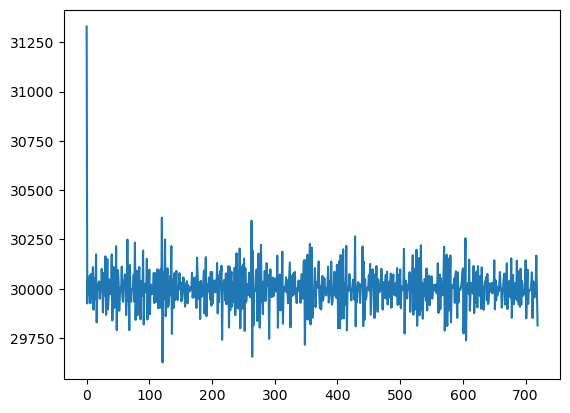

In [86]:
# See if there was any irregularity in frame timing by plotting the diff of relative_time_ms

plt.plot(
    trench11["relative_time_ms"].diff(dim="T")
)

# A simple kymograph

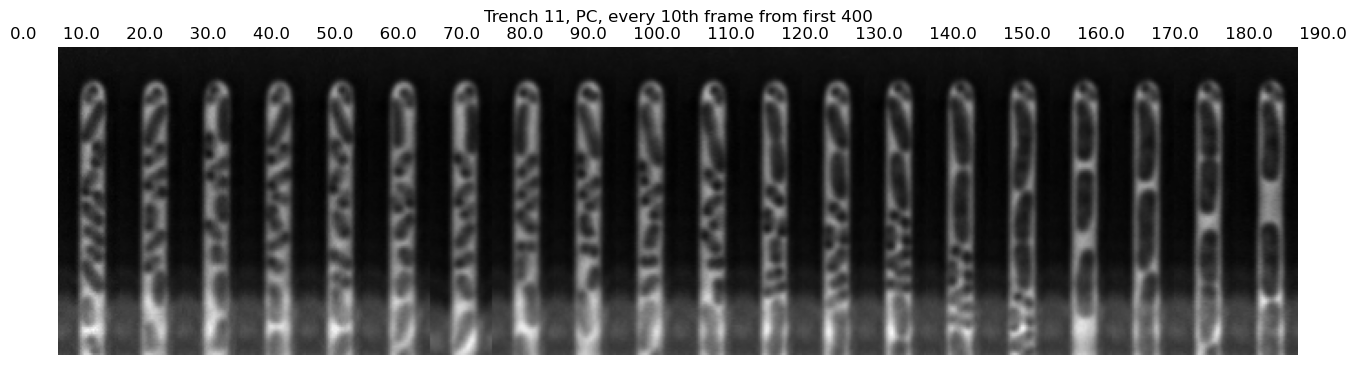

In [103]:
import numpy as np

pc_frames = trench11["data"].sel(C="PC").isel(T=slice(0, 400, 20)).compute()
pc_minutes = (
    trench11["relative_time_ms"].isel(T=slice(0, 400, 20)).compute().values / 60000
)
kymograph = np.concatenate(
    [pc_frames.isel(T=i).values for i in range(pc_frames.sizes["T"])],
    axis=1,
)

plt.figure(figsize=(16, 4))
plt.imshow(kymograph, cmap="gray", aspect="auto")
plt.axis("off")
plt.title(
    "Trench 11, PC, every 10th frame from first 400\n"
    + "     ".join(f"{value:.1f}" for value in pc_minutes)
)
plt.show()


## Suggested access patterns

- Use `root = xr.open_zarr(...)` for trench-first analysis.
- Use `root.isel(Trench=...)` or `root.sel(T=...)` to inspect one trench or one timepoint.
- Use `tree['source_frames'].ds` when you want source-frame metadata keyed by `(FOV, T)`.
- Use `tree['events'].ds.to_dataframe()` when you want a tabular view of event records.
- Use `tree['acquisition'].ds.attrs` and the acquisition variables for experiment-level metadata.
